# Dark Matter indirect search analysis with Gammapy

This tutorial covers a full analysis pipeline for the indirect search of dark matter using Gammapy.

We assume basic familiarity with Gammapy's data structures and the Dark Matter module. If you are new to Gammapy, we recommend first working through the introductory and the Dark Matter Basics and Data handling tutorials.

In this example we simulate observations of the **Draco dwarf spheroidal galaxy** and perform a **3D analysis** — using both spatial and spectral information, as opposed to a 1D (spectral-only) analysis (Check the Dark Matter Data handling tutorial for further details about these approaches).

The steps to follow in this tutorial are:
1. Data. We obtain and manage the data we are going to analyze. In this case will be the second option.
2. Analysis of signal detction. Conducting a statistical test we can determine if we have a signal or only backgrpund in our dataset.
3. Analysis products (profile likelihood limits, limits, brazilian plots) **PENDIENTE**


#### What We Are Constraining

Depending on the DM model assumed, the constrained quantity is different.

---

**Dark matter annihilation**

The expected gamma-ray flux from DM annihilation is:

$$\Phi_{\rm ann}(>E_{\rm min}) = \frac{\langle\sigma v\rangle}{8\pi m_\chi^2} 
\cdot J \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$

The physical quantity of interest is the **velocity-averaged annihilation cross section** ⟨σv⟩. A larger ⟨σv⟩ means a brighter signal. A non-detection gives an **upper limit** on ⟨σv⟩: the DM particles annihilate *at most* this efficiently.

In Gammapy's `DarkMatterAnnihilationSpectralModel`, ⟨σv⟩ is encoded through a dimensionless **`scale`** parameter:

$$\text{scale} = \frac{\langle\sigma v\rangle}{\langle\sigma v\rangle_{\rm ref}}$$

where $\langle\sigma v\rangle_{\rm ref} \approx 3\times10^{-26}$ cm³ s⁻¹ is the thermal relic value. An upper limit on `scale` translates directly into an upper limit on ⟨σv⟩:

$$\langle\sigma v\rangle < \text{scale}_{\rm UL} \times \langle\sigma v\rangle_{\rm ref}$$

---

**Dark matter decay**

The expected gamma-ray flux from DM decay is:

$$\Phi_{\rm dec}(>E_{\rm min}) = \frac{1}{4\pi \tau_\chi m_\chi} 
\cdot D \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$
The physical quantity of interest is the **DM lifetime** τ_χ. Note that it appears in the **denominator**: a *longer* lifetime means a *fainter* signal — the opposite behaviour from the annihilation case. A non-detection gives a **lower limit** on τ_χ: the DM particle must live *at least* this long.

In Gammapy's `DarkMatterDecaySpectralModel`, the lifetime is encoded through the same **`scale`** parameter, but now it multiplies the **decay rate** (inverse lifetime):

$$\text{scale} = \frac{1/\tau_\chi}{1/\tau_{\rm ref}} = \frac{\tau_{\rm ref}}{\tau_\chi}$$

where $\tau_{\rm ref}$ is an internal reference value (`LIFETIME_AGE_OF_UNIVERSE` ≈ 4.3 × 10¹⁷ s). Because of the inverse relationship, an **upper** limit on `scale` becomes a **lower** limit on τ_χ:

$$\tau_\chi > \frac{\tau_{\rm ref}}{\text{scale}_{\rm UL}}$$

In both cases, Gammapy reports an **upper limit on `scale`**, and you convert it to the physical quantity afterwards.

## Setup

In [417]:
from gammapy.data import Observation,FixedPointingInfo
from gammapy.datasets import MapDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import (
    MapDatasetMaker,
    SafeMaskMaker,
)
from gammapy.maps import MapAxis, WcsGeom
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    PointSpatialModel,
)
from gammapy.astro.darkmatter import (
    DarkMatterDecaySpectralModel,
    profiles,
    JFactory

)
from gammapy.modeling import Fit
from gammapy.estimators import ParameterEstimator

from regions import CircleSkyRegion

import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


## Analysis on DM source

In this section we simulate a dataset containing only background, mimicking the realistic scenario where no dark matter signal is present in the data. First we will do the analysis for one point (mass), obtaining its scale upper limits, and at the end we will make the implementation of a range mass.

### 1. Data

For this tutorial we will simulate observations of 500 hours of the **Draco dwarf spheroidal galaxy** using CTA-North IRFs (prod5 configuration), obtaining the counts with an Monte Carlo approach. Additionally, we are going to consider that the data follows an Einasto profile and we are going to study the case of Decay with channel b.

**For further detail in this step or if you want to use Real Data please check the tutorial XXX.**

In [388]:
# Source coordinates
draco_pos = SkyCoord(ra=260.05167 * u.deg, dec=57.915 * u.deg, frame="icrs")
draco_dist = 76 * u.kpc

# Location coordinates, i.e CTA-North
cta_norte = EarthLocation(lat=28.762 * u.deg, lon=-17.89 * u.deg, height=2200 * u.m)  

# Observation start time
obs_time = Time("2025-06-17 01:00:00")  # UTC

altaz = AltAz(obstime=obs_time, location=cta_norte)
draco_altaz = draco_pos.transform_to(altaz)

# Altitude and zenith angle
altitude = draco_altaz.alt.deg
zenith_angle = 90 - altitude

print(f"Altitude: {altitude:.2f}°")
print(f"Zenith angle: {zenith_angle:.2f}°")

Altitude: 60.82°
Zenith angle: 29.18°


In [ ]:
# Set energy bounds
energy_edges = np.logspace(-1, 2, 15) 
# The reconstructed energy axis, used for the final map and counts (i.e. what the telescope measures).
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")
# The true energy axis, used internally for the IRFs (e.g. effective area, energy dispersion), since the instrument's response is defined in terms of the true photon energy before any reconstruction effects.
energy_true  = MapAxis.from_edges(energy_edges, unit="TeV", name="energy_true", interp="log")

# Geometry map we are going to work with
geom_draco = WcsGeom.create(
    binsz=0.1, # Pixel size
    skydir=draco_pos, # Sky position of the target, center of the map
    width=3.0, # Width of the map (i.e 3x3 map)          
    frame="icrs", # Coordinates system
    axes=[energy_reco] 
)

In [390]:
# DM Spatial distribution 
spatial_model = PointSpatialModel(
    lon_0=draco_pos.ra,
    lat_0=draco_pos.dec,
    frame="icrs"
)

> **Note:** Computing these spectra requires the Gammapy datasets to be 
> downloaded and the `GAMMAPY_DATA` environment variable to be set. 
> Please follow the instructions at 
> https://docs.gammapy.org/dev/getting-started/index.html#recommended-setup 
> before running the cells below.

In [391]:
#import os
#os.environ["GAMMAPY_DATA"] = "PATH/gammapy-data"
import os 
os.environ["GAMMAPY_DATA"] ="/Users/alexcervino/Desktop/DARKMATTER/gammapy-data"

In [392]:
# DM spectral distribution

# DM parameters: mass and channel
channel = "b"
massDM = 10 * u.TeV

r_s = 0.91 * u.kpc # Scale radius
rho_s = 1.3e7 * (u.M_sun / u.kpc**3) # Scale density
rho_s_GeV = rho_s.to(u.GeV / u.cm**3, equivalencies=u.mass_energy()) # Units conversion

# Define the DM profile. Check profiles.DMProfile.__subclasses__() for more profiles
draco_profile = profiles.EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV
)

# Jfactor - This can also be calculated with the class JFactory, but we set the value for simplicity. You can look for it in dedicated papers.
# for calculating the JFactory see Tutorial XXXX

dfactory = JFactory(
    geom=geom_draco, # Geometry map
    profile=draco_profile, # Chosen density profile
    distance=draco_dist, # Target distance
    annihilation = False # Set if it is annihilation (true) or decay (false)
)

# Computation of the J factor
dfact_draco = dfactory.compute_jfactor() 

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=draco_pos, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_draco.wcs)

# Integration of DFactor within that region
total_dfact = pix_reg.to_mask().multiply(dfact_draco).sum()

spectral_model = DarkMatterDecaySpectralModel(
    mass=massDM,
    channel=channel, 
    jfactor=total_dfact, 
    scale=0 # Example so we do NOT get a signal
)

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


In [393]:
# Combined model
model_simu = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="draco-dm"
)

In [394]:
# Background model
bkg_model = FoVBackgroundModel(dataset_name="dataset-simu-draco")

In [ ]:
# Load IRFs
irf_path = "$GAMMAPY_DATA/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits"
irfs = load_irf_dict_from_file(irf_path)

# Create the Observation: 500 hours of livetime
livetime = 500 * u.h
obs = Observation.create(
    pointing=FixedPointingInfo(fixed_icrs=draco_pos), 
    livetime=livetime, 
    irfs=irfs, 
    reference_time=obs_time
)

Invalid unit found in background table! Assuming (s-1 MeV-1 sr-1)


In [396]:
# Dataset creation
# Create an empty MapDataset
empty = MapDataset.create(geom=geom_draco, name="dataset-simu-draco", energy_axis_true=energy_true)

# Setup Maker to calculate exposure, background, PSF, and energy dispersion
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])

# Safe mask
maker_safe_mask = SafeMaskMaker(
    methods=["offset-max"], 
    offset_max=2.5 * u.deg)

# Run the maker and attach models
dataset = maker.run(empty, obs)
dataset = maker_safe_mask.run(dataset, obs)

# Attach the DM model and a Field-of-View background model
dataset.models = Models([model_simu, bkg_model])

In [397]:
# Counts simulation
aux_dataset = dataset
dataset_mc = aux_dataset

# Sample Poisson fluctuations around the prediction
# random_state fixes the seed for reproducibility, but it may be random
dataset_mc.fake(random_state=44) 

print("=== MC Observation ===")
# We do not expect the same counts since the statistical noise is introduced
print(f"Predicted counts : {dataset_mc.npred().data.sum():.2f}")
print(f"Simulated counts : {dataset_mc.counts.data.sum()}")


=== MC Observation ===
Predicted counts : 13257962.46
Simulated counts : 13254247.0


### 2. Analysis of signal detection
To verify that our simulated dataset contains no dark matter signal, we perform a **likelihood ratio test** between two hypotheses:

- **H₀ (background-only):** the dataset is described by the background model alone
- **H₁ (signal + background):** a dark matter spectral component is included

We fit both models to the dataset and compute the Test Statistic - the fitting technicla details will be explained in the next sections:

$$\text{TS} = -2\ln\frac{\mathcal{L}(\text{H}_0)}{\mathcal{L}(\text{H}_1)} = \text{stat}_{H_0} - \text{stat}_{H_1}$$

As a rule of thumb, $\sqrt{\text{TS}}$ approximates the detection significance in Gaussian sigmas — a value of TS = 25 corresponds to a $5\sigma$ detection. The brighter the injected signal, the larger the TS. Under the background-only hypothesis, we expect **TS ≈ 0**, meaning the fitterfinds no evidence for a dark matter signal in the data.

Gammapy's `Fit` class provides a unified interface to several optimization backends; by default it uses [iminuit](https://iminuit.readthedocs.io/), a Python wrapper around the MINUIT2 C++ library originally developed at CERN, the de facto standard optimizer in high-energy and astroparticle physics. MINUIT performs a maximum-likelihood fit and additionally provides robust parameter errors and covariance estimates via the Hesse and Minos algorithms.

During the fit, the optimizer adjusts all **free** parameters of the model — the background normalization parameters (or `scale` (related to ⟨σv⟩ or 1/τ_χ, depending on whether we are studying annihilation or decay) if you are making a signal study) — to maximize the Poisson likelihood between the observed (or simulated) counts and the model prediction. All other parameters remain fixed at their assumed values.

**PONER QUE HAY PRAMTERS QUE SE PUEDEN AJUSTAR PARA EL FIT**



In [398]:
# First check the parameters of the model
display(dataset_mc.models.parameters.to_table())

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str3,float64,float64,float64,bool,str1,str1
,scale,0.0000e+00,,0.000e+00,nan,nan,False,,
,lon_0,2.6005e+02,deg,0.000e+00,nan,nan,False,,
,lat_0,5.7915e+01,deg,0.000e+00,-9.000e+01,9.000e+01,False,,
,tilt,0.0000e+00,,0.000e+00,nan,nan,True,,
,norm,1.0000e+00,,0.000e+00,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,


We see that the coordinates are free parameters, we should freeze them so we make sure we study teh target we want.

In [399]:
dataset_mc.models["draco-dm"].parameters['lon_0'].frozen = True
dataset_mc.models["draco-dm"].parameters['lat_0'].frozen = True

In [400]:
# Fit with background only (no DM signal)
# Freeze the DM model parameters and free the background model parameters
dataset_mc.models["draco-dm"].spectral_model.scale.frozen = True
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].frozen = False
dataset_mc.models["dataset-simu-draco-bkg"].parameters["tilt"].frozen = False

fit = Fit()
result_bkg = fit.run(datasets=[dataset_mc])
print(f"Background fit converged: {result_bkg.success}")

if not result_bkg.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H0 = dataset_mc.stat_sum()
    print(f"         stat_H0 = {stat_H0:.4f}")

# Another way to do the background-only fit is to create a new model with only the background component and assign it to the dataset. This is useful if you want to keep the original model intact for later use.
# Here you have the code sample
#models_nosrc = Models([bkg_model])
#dataset_mc.models = models_nosrc
#fit = Fit()
#result_nosrc = fit.run(datasets=[dataset_mc])

Background fit converged: True
         stat_H0 = -191119044.7649


If fit does not converge, you can try to adjust the initial parameters setting a starting value, minimun or maximum, but make sure it converges before getting to the next step. Here we leave an example.

In [401]:
# Example of how to set the background normalization parameter for a specific dataset. This is useful when you want to adjust the background model's normalization before fitting or analyzing the data.
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].value = 1.0 # Starting point of the optimizer
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].min = 0.5
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].max = 2.0

fit = Fit()
result_bkg = fit.run(datasets=[dataset_mc])
print(f"Background fit converged: {result_bkg.success}")

if not result_bkg.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H0 = result_bkg.total_stat
    print(f"         stat_H0 = {stat_H0:.4f}")

Background fit converged: True
         stat_H0 = -191119044.7651


Once it has converged, we can proceed with the H1 fit.

In [421]:
# Full fit — all parameters free
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].frozen = True
dataset_mc.models["dataset-simu-draco-bkg"].parameters["tilt"].frozen = True
dataset_mc.models["draco-dm"].spectral_model.scale.frozen = False

result_full = fit.run(datasets=[dataset_mc])
print(f"Background fit converged: {result_bkg.success}")
print(f"Full fit converged: {result_full.success}")

if not result_full.success:
    print("WARNING: fit did not converge. Adjust starting values before continuing.")
else:
    stat_H1 = result_full.total_stat
    print(f"         stat_H1 = {stat_H1:.4f}")

#Another way to do the full fit is to create a new model with both the DM and background components and assign it to the dataset. This is useful if you want to keep the original model intact for later use.
# Here you have the code sample
#spectral_model.parameters["scale"].frozen = False
#models_src = Models([model_simu, bkg_model])
#dataset_mc.models = models_src
#result_src = fit.run(datasets=[dataset_mc])

Background fit converged: True
Full fit converged: True
         stat_H1 = -191119044.7651


finally, when both fits are successful, we can proceed witht he calculation of the TS.

In [422]:
TS = stat_H0 - stat_H1
print(f"TS = {TS:.2f}")  # Expected ~ 0 for background-only dataset

TS = 0.00


As aforementioned, the TS value is expected to be around 0 for a background-only dataset, indicating that the addition of the DM signal does not significantly improve the fit. This is consistent with our simulation where we set the scale of the DM signal to 0, effectively simulating a scenario with no dark matter contribution.

Additionally, we can make a visual check of our data to verify this result.

[]

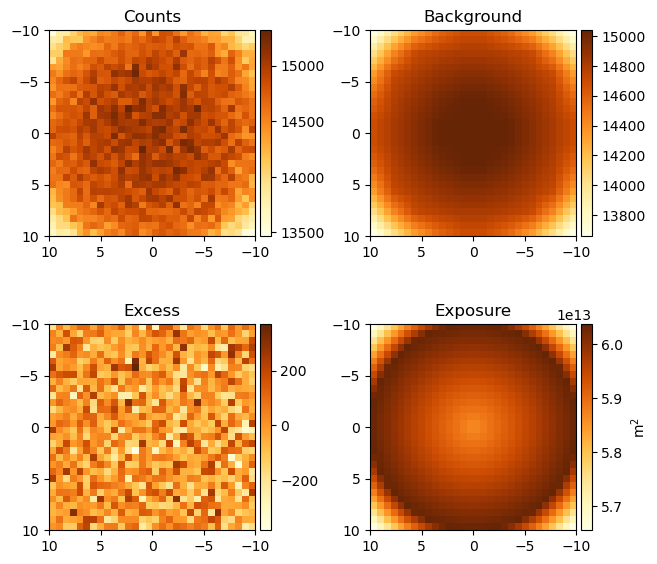

In [404]:
fig_peek, axs = plt.subplots(2,2, figsize=(7,7))

img_1 = axs[0,0].imshow(
    np.sum(dataset_mc.counts.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr',
)
axs[0,0].set_title('Counts')
divider = make_axes_locatable(axs[0,0])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_1 = fig_peek.colorbar(img_1, cax=cax, orientation='vertical')

img_2 = axs[0,1].imshow(
    np.sum(dataset_mc.background.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[0,1].set_title('Background')
divider = make_axes_locatable(axs[0,1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_2 = fig_peek.colorbar(img_2, cax=cax, orientation='vertical')

img_3 = axs[1,0].imshow(
    np.sum(dataset_mc.counts.data, axis=0) - np.sum(dataset_mc.background.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[1,0].set_title('Excess')
divider = make_axes_locatable(axs[1,0])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_3 = fig_peek.colorbar(img_3, cax=cax, orientation='vertical')

img_4 = axs[1,1].imshow(
    np.sum(dataset_mc.exposure.data, axis=0),
    extent=(10.0+0.0,-10.0+0.0,10.0+0.0,-10.0+0.0),
    origin = 'lower',
    cmap='YlOrBr'
)
axs[1,1].set_title('Exposure')

divider = make_axes_locatable(axs[1,1])
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar_4 = fig_peek.colorbar(img_4, cax=cax, orientation='vertical')
cbar_4.ax.set_ylabel(r'm$^2$')

fig_peek.subplots_adjust(wspace=0.45, hspace=0.2)

plt.plot()

[]

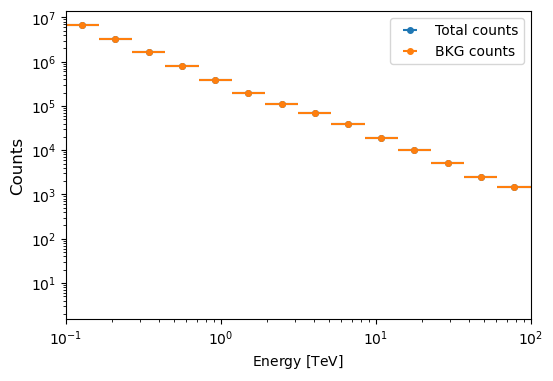

In [405]:
# Let's check the spectrum and the different contributions
spec, axs = plt.subplots(1, 1, figsize=(6, 4))
dataset_mc.counts.get_spectrum().plot(label='Total counts')
dataset_mc.npred_background().get_spectrum().plot(label='BKG counts')

axs.set_ylabel('Counts', fontsize=12)
axs.legend()
plt.plot()

/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encou

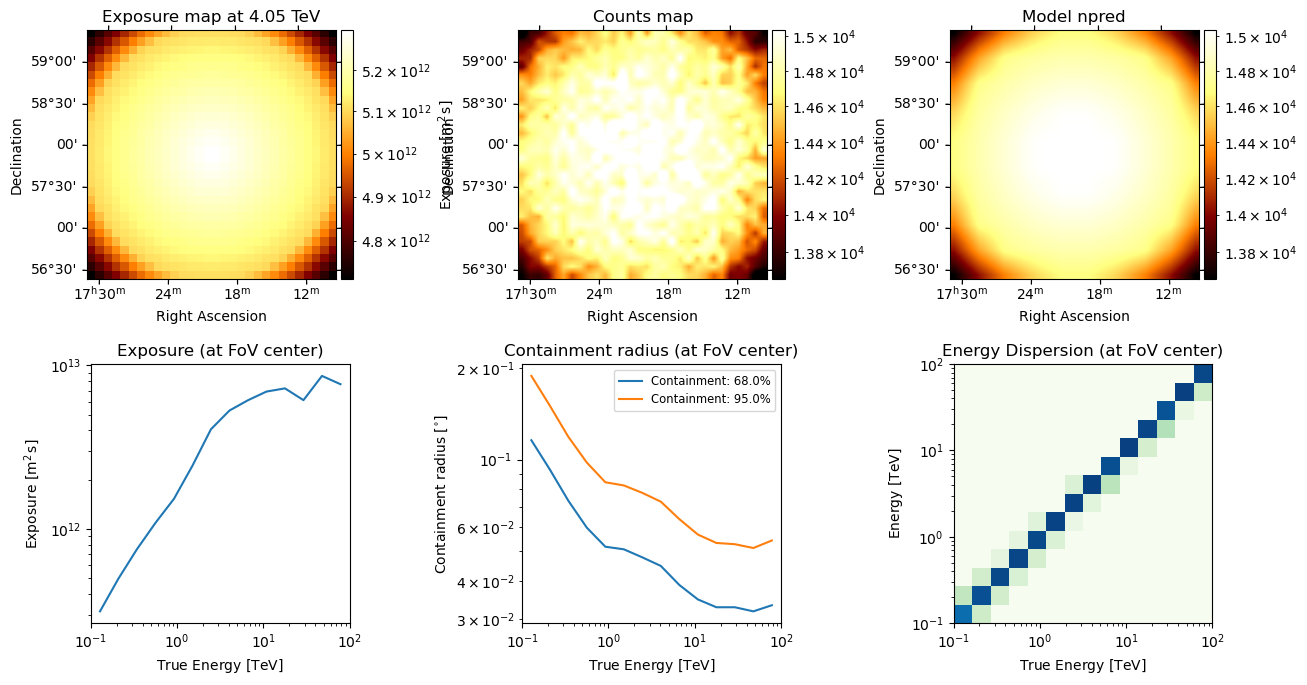

In [406]:
dataset_mc.peek()

### 3. No Signal: From Dataset to Limits

TWe did not detect a signal, but we can still place a **constraint** on the DM parameter of interest — we can exclude signal amplitudes large enough to be inconsistent with what we observed.

---

#### The Profile Likelihood

We use the **profile likelihood** to derive the upper limit. The idea is simple: we scan `scale` over a grid of values and ask how much the likelihood degrades at each point:

$$\Delta \text{TS}(\text{scale}) = \text{stat}(\text{scale}) - 
\text{stat}(\hat{\text{scale}})$$

where $\hat{\text{scale}}$ is the best-fit value. 

By Wilks' theorem, the **95% CL upper limit** corresponds to the value of `scale` where:

$$\boxed{\Delta \text{TS} = 2.71}$$

---

In [407]:
# ── Reset scale to a clean starting point ────────────────────────────────────
spectral_model.scale.value  = 1e-6
spectral_model.scale.min    = 0
spectral_model.scale.max    = None
spectral_model.scale.frozen = False

# ── Release background parameters ────────────────────────────────────────────
dataset_mc.models["dataset-simu-draco-bkg"].parameters["norm"].frozen = False
dataset_mc.models["dataset-simu-draco-bkg"].parameters["tilt"].frozen = False

scale_par = dataset_mc.models["draco-dm"].spectral_model.scale
scale_par.scan_values = np.logspace(-10, -2, 300)

print(f"Scan range:       {scale_par.scan_values.min():.1e}"
      f" — {scale_par.scan_values.max():.1e}")
print(f"Number of points: {len(scale_par.scan_values)}")
print("Running profile scan (this may take a few minutes)...")

# ── Run the profile likelihood ────────────────────────────────────────────────
profile = fit.stat_profile(
    datasets=dataset_mc,
    parameter=scale_par,
    reoptimize=True,    # re-optimize background at each scan point
)

print("Profile scan completed ✓")

Scan range:       1.0e-10 — 1.0e-02
Number of points: 300
Running profile scan (this may take a few minutes)...
Profile scan completed ✓


In [408]:
# ── Extract arrays ────────────────────────────────────────────────────────────
scale_scan = profile["draco-dm.spectral.scale_scan"]
delta_ts   = profile["stat_scan"] - profile["stat_scan"].min()

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"Minimum ΔTS: {delta_ts.min():.4f}  (should be ≈ 0)")
print(f"Maximum ΔTS: {delta_ts.max():.2f}   (must be > 2.71 to find UL)")

Minimum ΔTS: 0.0000  (should be ≈ 0)
Maximum ΔTS: 2637206195.48   (must be > 2.71 to find UL)


We see that the maximum ΔTS is bigger than 2.71, so we can compute the upper limit of the scale and convert it into a physical value for our study case. If this wasn't the case, we must reconsiderer the configuration for the scan (i.e. scan_max...) and run again.

In [423]:
# ── Find scale_ul: crossing at ΔTS = 2.71 on the right branch ────────────────
# We interpolate only on the right side of the minimum (upper limit side)
idx_min  = np.argmin(delta_ts)
scale_ul = np.interp(2.71,
                     delta_ts[idx_min:],
                     scale_scan[idx_min:])

# ── Convert to physical limits ────────────────────────────────────────────────

# Decay: scale = τ_ref / τ_χ  →  τ_χ > τ_ref / scale_ul
tau_ref         = spectral_model.LIFETIME_AGE_OF_UNIVERSE   # ~4.3e17 s
tau_lower_limit = tau_ref / scale_ul

#Here you have the example for the case of annihilation, but we are not going to use it in this tutorial since we are working with decay.
# Annihilation (for reference): scale = <σv> / <σv>_ref  →  <σv> < scale_ul × <σv>_ref
# sigma_v_ref = 3e-26 * u.Unit("cm3 s-1")
# sigma_v_ul  = scale_ul * sigma_v_ref

print(f"  DM mass:    {massDM}")
print(f"  Channel:    {channel}")
print(f"  Livetime:   {livetime}")
print(f"  scale UL (95% CL):          {scale_ul:.3e}")
print(f"  Lifetime lower limit (95% CL): {tau_lower_limit:.3e} s")

  DM mass:    10.0 TeV
  Channel:    b
  Livetime:   500.0 h
  scale UL (95% CL):          3.524e-09
  Lifetime lower limit (95% CL): 1.220e+26 s s


Now we plot the profile likelihood **interpretar**

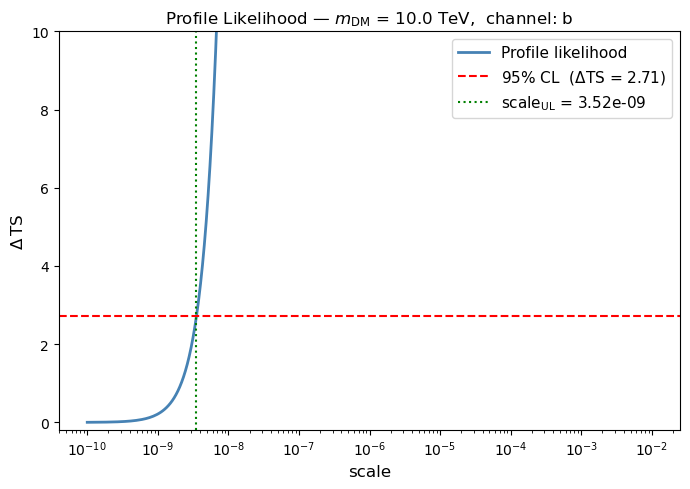

In [410]:
fig, ax = plt.subplots(figsize=(7, 5))

# ── Profile curve ─────────────────────────────────────────────────────────────
ax.plot(scale_scan, delta_ts,
        color="steelblue", linewidth=2,
        label="Profile likelihood")

# ── 95% CL threshold ──────────────────────────────────────────────────────────
ax.axhline(2.71,
           color="red", linestyle="--", linewidth=1.5,
           label=r"95% CL  ($\Delta$TS = 2.71)")

# ── Upper limit marker ────────────────────────────────────────────────────────
ax.axvline(scale_ul,
           color="green", linestyle=":", linewidth=1.5,
           label=f"scale$_{{\\rm UL}}$ = {scale_ul:.2e}")

ax.set_xscale("log")
ax.set_xlabel("scale", fontsize=12)
ax.set_ylabel(r"$\Delta\,\mathrm{TS}$", fontsize=12)
ax.set_ylim(-0.2, 10)
ax.legend(fontsize=11)
ax.set_title(
    rf"Profile Likelihood — $m_{{\rm DM}}$ = {massDM},  "
    rf"channel: {channel}",
    fontsize=12
)
plt.tight_layout()
plt.show()

The minimum sits at `scale ≈ 0`, as expected for a background-only dataset: the data show no preference for a nonzero DM signal. The curve rises monotonically from there — more signal means more predicted counts than observed, so the fit degrades and ΔTS grows.

The **95% CL upper limit** is where the curve crosses ΔTS = 2.71 (Wilks' theorem, one-sided test on a boundary parameter). Everything to the right is excluded; everything to the left remains compatible with the data.

Because the minimum sits at the boundary with ΔTS ≈ 0 throughout (no hint of detection), a **one-sided limit** is the correct quantity to report here — not a two-sided interval (see the aside below on what would change if TS were large instead). Converting `scale_ul` to a lower limit on $\tau_\chi$ is just a change of variable on this same statement: *decay lifetimes shorter than this value are excluded at 95% CL*.

For the decay case, this translates into a **lower limit on the DM lifetime**: the DM particle must live at least as long as $\tau_\chi > \tau_{\rm ref} / \text{scale}_{\rm UL}$. For the annihilation case, it gives an **upper limit on the annihilation cross section**: $\langle\sigma v\rangle < \text{scale}_{\rm UL} \times \langle\sigma v\rangle_{\rm ref}$.

### Another mehthod: `ParameterEstimator`

`ParameterEstimator` can give you the best fit, symmetric error, TS, and (optionally) upper limit in one call. It doesn't return a two-sided profile-likelihood interval directly (that's what the manual scan above is for), but it's a fast sanity check on the significance and the Hessian error.

In [ ]:
estimator = ParameterEstimator(
    n_sigma=1, # level for symmetric error (1σ = 68%)
    n_sigma_ul=1.645, # level for upper limit (2σ ≈ 95%)
    selection_optional=["ul"], # ask to also compute the UL
)
result_par = estimator.run(datasets=[dataset_mc], parameter="scale")

print(f"Scale (best fit)      : {result_par['scale']:.4g}")
print(f"Scale upper limit     : {result_par['scale_ul']:.4g}")
print(f"TS                    : {result_par['ts']:.2f}")
print(f"sqrt(TS)              : {np.sqrt(max(result_par['ts'], 0)):.2f} sigma")

---

#### Aside: what if we *had* detected a signal?

If the fit above had returned **TS ≫ 0** (instead of TS ≈ 0), the interpretation — and the quantity we report — would change completely. A one-sided upper limit is only meaningful when the best-fit value sits at or near the physical boundary (`scale = 0`), i.e. when there is **no evidence for a signal**.

If a real signal were present, we would **stop here** and instead report a **best-fit value with a two-sided confidence interval**, using the *same* profiled likelihood but reading it differently:

$$\Delta \text{TS} = 1.0 \;\Rightarrow\; \text{68\% CL interval}$$
$$\Delta \text{TS} = 3.84 \;\Rightarrow\; \text{95\% CL interval}$$

read on **both branches** of the minimum, around the best-fit $\hat{\text{scale}}$ — not just the upper branch from zero as in the one-sided limit above.

The decision of which quantity to report is not a stylistic choice: reporting a one-sided upper limit when TS indicates a clear detection would hide the fact that a signal was found, while reporting a two-sided interval when TS ≈ 0 would misleadingly suggest a measurement where there is only background fluctuation (see e.g. Feldman & Cousins 1998; Rolke et al. 2005). A simple decision rule based on the value of TS is typically used to choose between the two regimes automatically.

The code below illustrates how this would look — **it is not executed in this tutorial**, since our dataset has TS ≈ 0 and the one-sided limit above is the correct result to report.

In [413]:
# ── EXAMPLE ONLY — not executed in this tutorial (TS ≈ 0 here) ──────────────
# This is what you would run instead of the one-sided UL block above,
# if the fit had returned TS >> 0 (a real detection).

idx_min  = np.argmin(delta_ts)
best_fit = scale_scan[idx_min]

# Two-sided 68% CL interval (both branches around the minimum)
lo_branch = delta_ts[:idx_min + 1]
hi_branch = delta_ts[idx_min:]

scale_lo = np.interp(1.0, lo_branch[::-1], scale_scan[:idx_min + 1][::-1])
scale_hi = np.interp(1.0, hi_branch,       scale_scan[idx_min:])

print(f"Best-fit scale        : {best_fit:.3e}")
print(f"68% CL interval        : [{scale_lo:.3e}, {scale_hi:.3e}]")

# Converted to the physical quantity (decay case)
tau_ref  = spectral_model.LIFETIME_AGE_OF_UNIVERSE
tau_best = tau_ref / best_fit
tau_hi   = tau_ref / scale_lo   # inverse relation: swap bounds
tau_lo   = tau_ref / scale_hi

print(f"Best-fit tau_chi       : {tau_best:.3e}")
print(f"68% CL interval on tau : [{tau_lo:.3e}, {tau_hi:.3e}]")

Best-fit scale        : 1.000e-10
68% CL interval        : [1.000e-10, 2.146e-09]
Best-fit tau_chi       : 4.300e+27 s
68% CL interval on tau : [2.003e+26 s, 4.300e+27 s]


### 4. Exclusion Curve: Scanning Over DM Masses

So far we have derived an upper limit for a single DM mass. To build the full **exclusion curve** — the standard output of a DM indirect detection analysis — we repeat the same procedure over a grid of masses.

For each mass we:
1. Update the spectral model to the new mass
2. Simulate a background-only dataset
3. Fit the background
4. Run the profile scan → `scale_ul`
5. Convert to a physical limit (τ_χ or ⟨σv⟩)

The result is a curve of lower limits on τ_χ (or upper limits on ⟨σv⟩) as a function of DM mass.

In [ ]:
# Mass range we want to scan.
masses = np.logspace(2, 4, 100) * u.GeV

# Scan grid (adjust if needed per mass)
scale_values = np.logspace(-100, -2, 100)

# Output containers
results = {
    "mass"     : [],
    "scale_ul" : [],
    "scale_ll"   : []   # lower limit on scale
}

fit = Fit()

print(f"Running exclusion curve over {len(masses)} masses...")
for mass in masses:

    print(f"  mass = {mass}  ...", end=" ")

    spectral_model_m = DarkMatterDecaySpectralModel(
        mass=mass,
        channel=channel,
        jfactor=total_dfact,      # o como lo tengas definido
    )
    spectral_model_m.scale.value  = 0
    spectral_model_m.scale.frozen = True
    spectral_model_m.scale.min    = 0

    sky_model_m = SkyModel(
        spatial_model=spatial_model,
        spectral_model=spectral_model_m,
        name="draco-dm"
    )

    dataset_mc.models = Models([sky_model_m, bkg_model])

    # ── Verificar que la señal cambia ─────────────────────────────────────────
    spectral_model_m.scale.value = 1e-7
    npred_sig = dataset_mc.npred_signal().data.sum()
    print(f"npred_signal = {npred_sig:.4e}", end=" ... ")
    spectral_model_m.scale.value = 0

    # ── Profile scan ──────────────────────────────────────────────────────────
    spectral_model_m.scale.value  = 1e-7
    spectral_model_m.scale.frozen = False

    scale_par_m = dataset_mc.models["draco-dm"].spectral_model.scale
    scale_par_m.scan_values = scale_values

    profile_m = fit.stat_profile(
        datasets=dataset_mc,
        parameter=scale_par_m,
        reoptimize=False,
    )

    scale_scan_m = profile_m["draco-dm.spectral.scale_scan"]
    delta_ts_m   = profile_m["stat_scan"] - profile_m["stat_scan"].min()

    if delta_ts_m.max() < 2.71:
        print("profile did not reach ΔTS=2.71, skipping.")
        continue

    idx_min  = np.argmin(delta_ts_m)
    scale_ul = np.interp(2.71,
                         delta_ts_m[idx_min:],
                         scale_scan_m[idx_min:])

    tau_ref = spectral_model_m.LIFETIME_AGE_OF_UNIVERSE
    tau_ll  = tau_ref / scale_ul

    results["mass"].append(mass.to("TeV").value)
    results["scale_ul"].append(scale_ul)
    results["scale_ll"].append(tau_ll.value)

    print(f"scale_ul = {scale_ul:.3e}  |  τ_χ > {tau_ll:.3e}")

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


Running exclusion curve over 10 masses...
  mass = 200.0 GeV  ... npred_signal = 0.0000e+00 ... 

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


profile did not reach ΔTS=2.71, skipping.
  mass = 1200.0 GeV  ... npred_signal = 1.3522e+03 ... 

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


...

scale_ul = 5.098e-09  |  τ_χ > 8.435e+25 s
  mass = 7200.0 GeV  ... npred_signal = 1.1353e+04 ... 

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


scale_ul = 4.451e-09  |  τ_χ > 9.661e+25 s
  mass = 8200.0 GeV  ... npred_signal = 1.2123e+04 ... 

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


scale_ul = 4.023e-09  |  τ_χ > 1.069e+26 s
  mass = 9200.0 GeV  ... npred_signal = 1.2772e+04 ... scale_ul = 3.696e-09  |  τ_χ > 1.163e+26 s


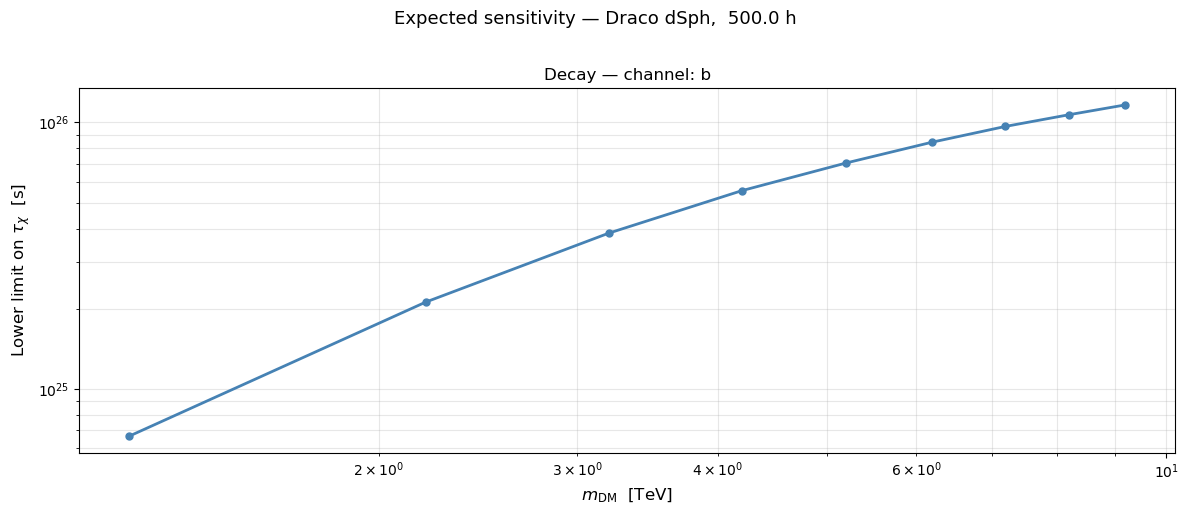

In [415]:
fig, ax = plt.subplots(1, figsize=(12, 5))

mass_arr    = np.array(results["mass"])
scale_arr   = np.array(results["scale_ll"])

# ── Decay: lower limit on scale ────────────────────────────────────────────────
ax.plot(mass_arr, scale_arr,
        color="steelblue", linewidth=2, marker="o", markersize=5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_{\rm DM}$  [TeV]", fontsize=12)
ax.set_ylabel(r"Lower limit on $\tau_\chi$  [s]", fontsize=12)
ax.set_title(rf"Decay — channel: {channel}", fontsize=12)
ax.grid(True, which="both", alpha=0.3)

plt.suptitle(rf"Expected sensitivity — Draco dSph,  {livetime}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the Exclusion Curve

The plot above shows the **expected lower limit on the DM lifetime**, $\tau_\chi$, as a function of DM mass, for a single background-only Monte
Carlo realization.

A few things to note when reading this curve:

- **The curve sets a floor, not a measurement.** Every point says "given this dataset, we can exclude $\tau_\chi$ shorter than this value at 95% CL" — it is *not* a best-fit lifetime, since no signal was detected (recall $\mathrm{TS} \approx 0$ throughout).
- **Higher on the plot is a stronger (more constraining) limit.** A larger lower bound on $\tau_\chi$ means the analysis is more sensitive to that particular DM mass — i.e. it can rule out shorter (and therefore brighter) lifetimes more effectively.
- **The overall shape reflects a combination of two effects**: the instrument's effective area and angular resolution as a function of energy (peaking in the CTA core energy range), and the shape of the DM decay spectrum $dN/dE$ for the chosen channel, which shifts and broadens with mass. This is why sensitivity is typically *not* monotonic across the full mass range — it usually improves, plateaus, and can degrade again outside the instrument's best-covered energies.
- **Points that could not be constrained are simply absent.** If a given mass's profile scan never reaches $\Delta\mathrm{TS} = 2.71$ within the scanned `scale` range, that mass is skipped rather than
  plotted with a misleading extrapolated value.

Keep in mind this single curve is subject to the specific Poisson fluctuation of the one background realization it was built from — a different simulated dataset (same true background model, different noise) would trace a slightly different curve. That variability is exactly what the Brazilian plot in the next section quantifies.

### 5. Brazilian Plot: Uncertainty Bands on the Exclusion Curve

The exclusion curve derived in the previous section is based on a **single background realization**: a different Poisson fluctuation would give a slightly different curve. To quantify this uncertainty, we now repeat the profile scan over many background-only realizations per mass and take the percentiles of the resulting distribution of limits.

For each mass we generate `n_realizations` datasets with different Poisson noise, compute one `scale_ul` per realization, and convert to τ_χ. The percentiles give the **1σ** (green) and **2σ** (yellow) bands around the median expected limit.

One important note: the conversion from `scale_ul` to τ_χ **inverts the order of the percentiles** — a large `scale_ul` (weak limit on scale) corresponds to a small τ_χ (weak limit on lifetime), so the bands flip when converting to physical units:

$$\tau_{\rm p16} = \frac{\tau_{\rm ref}}{\text{scale}_{\rm p84}} \qquad 
\tau_{\rm p84} = \frac{\tau_{\rm ref}}{\text{scale}_{\rm p16}}$$

The single MC realization from the previous section will appear as a dotted line inside the bands — a sanity check that it falls within the expected range.

In [416]:
n_realizations = 100
scale_values   = np.logspace(-10, -2, 80)

brazil = {
    "mass" : [],
    "p025" : [],
    "p16"  : [],
    "p50"  : [],
    "p84"  : [],
    "p975" : [],
}

fit = Fit()

print(f"Running Brazilian plot: {len(masses)} masses × {n_realizations} realizations")
print("─" * 55)

for mass in masses:

    print(f"\n  mass = {mass}")
    scale_ul_mc = []

    for i in range(n_realizations):

        # ── Recreate spectral model with this mass ────────────────────────────
        spectral_model_i = DarkMatterDecaySpectralModel(
            mass=mass,
            channel=channel,
            jfactor=total_dfact,
        )
        spectral_model_i.scale.value  = 0
        spectral_model_i.scale.frozen = True
        spectral_model_i.scale.min    = 0

        bkg_model_i = FoVBackgroundModel(
            dataset_name=f"dataset-{mass.value:.0f}GeV-{i}"
        )
        bkg_model_i.parameters["norm"].frozen = False
        bkg_model_i.parameters["tilt"].frozen = False

        dataset_i = dataset.copy(
            name=f"dataset-{mass.value:.0f}GeV-{i}"
        )
        dataset_i.models = Models([
            SkyModel(spatial_model=spatial_model,
                     spectral_model=spectral_model_i,
                     name="draco-dm"),
            bkg_model_i
        ])

        # ── Generate Poisson realization ──────────────────────────────────────
        dataset_i.fake(random_state=i)

        # ── Fit background (scale frozen) ─────────────────────────────────────
        result_i = fit.run(datasets=[dataset_i])
        if not result_i.success:
            continue

        # ── Freeze background at best-fit ─────────────────────────────────────
        bkg_model_i.parameters["norm"].frozen = True
        bkg_model_i.parameters["tilt"].frozen = True

        # ── Profile scan ──────────────────────────────────────────────────────
        spectral_model_i.scale.value  = 1e-7
        spectral_model_i.scale.frozen = False

        scale_par_i = dataset_i.models["draco-dm"].spectral_model.scale
        scale_par_i.scan_values = scale_values

        profile_i = fit.stat_profile(
            datasets=dataset_i,
            parameter=scale_par_i,
            reoptimize=True,
        )

        scale_scan_i = profile_i["draco-dm.spectral.scale_scan"]
        delta_ts_i   = profile_i["stat_scan"] - profile_i["stat_scan"].min()

        if delta_ts_i.max() < 2.71:
            continue

        idx_min  = np.argmin(delta_ts_i)
        scale_ul = np.interp(2.71,
                             delta_ts_i[idx_min:],
                             scale_scan_i[idx_min:])
        scale_ul_mc.append(scale_ul)

    # ── Compute percentiles for this mass ─────────────────────────────────────
    if len(scale_ul_mc) < 10:
        print(f"    Too few valid realizations ({len(scale_ul_mc)}), skipping.")
        continue

    scale_ul_array = np.array(scale_ul_mc)
    tau_ref        = spectral_model_i.LIFETIME_AGE_OF_UNIVERSE

    # Invert percentile order when converting scale → τ_χ
    p025 = tau_ref / np.percentile(scale_ul_array, 97.5)
    p16  = tau_ref / np.percentile(scale_ul_array, 84)
    p50  = tau_ref / np.percentile(scale_ul_array, 50)
    p84  = tau_ref / np.percentile(scale_ul_array, 16)
    p975 = tau_ref / np.percentile(scale_ul_array, 2.5)

    brazil["mass"].append(mass.to("TeV").value)
    brazil["p025"].append(p025.value)
    brazil["p16"].append(p16.value)
    brazil["p50"].append(p50.value)
    brazil["p84"].append(p84.value)
    brazil["p975"].append(p975.value)

    print(f"    valid: {len(scale_ul_mc)}/{n_realizations}  |  "
          f"median τ_χ > {p50:.2e}")

print("\n" + "─" * 55)
print(f"Done. {len(brazil['mass'])} mass points computed.")

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


Running Brazilian plot: 10 masses × 100 realizations
───────────────────────────────────────────────────────

  mass = 200.0 GeV


The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model wi

    Too few valid realizations (0), skipping.

  mass = 1200.0 GeV


The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model wi

    valid: 100/100  |  median τ_χ > 9.19e+24 s

  mass = 2200.0 GeV


The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model wi

KeyboardInterrupt: 

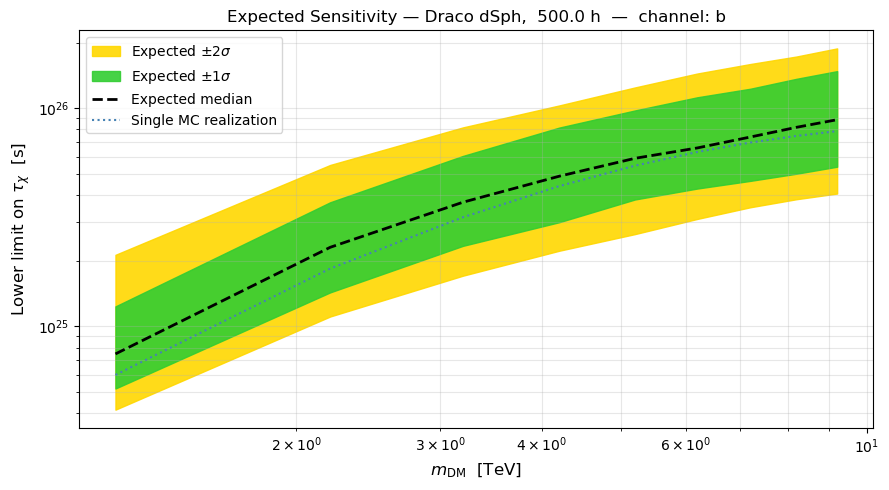

In [ ]:
mass_arr = np.array(brazil["mass"])
p025_arr = np.array(brazil["p025"])
p16_arr  = np.array(brazil["p16"])
p50_arr  = np.array(brazil["p50"])
p84_arr  = np.array(brazil["p84"])
p975_arr = np.array(brazil["p975"])

fig, ax = plt.subplots(figsize=(9, 5))

# ── 2σ band (yellow) ──────────────────────────────────────────────────────────
ax.fill_between(mass_arr, p025_arr, p975_arr,
                color="gold", alpha=0.9,
                label=r"Expected $\pm 2\sigma$")

# ── 1σ band (green) ───────────────────────────────────────────────────────────
ax.fill_between(mass_arr, p16_arr, p84_arr,
                color="limegreen", alpha=0.9,
                label=r"Expected $\pm 1\sigma$")

# ── Median ────────────────────────────────────────────────────────────────────
ax.plot(mass_arr, p50_arr,
        color="black", linewidth=2, linestyle="--",
        label="Expected median")

# ── Single MC realization from Section 4 ─────────────────────────────────────
ax.plot(results["mass"], results["scale_ll"],
        color="steelblue", linewidth=1.5, linestyle=":",
        label="Single MC realization")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_{\rm DM}$  [TeV]", fontsize=12)
ax.set_ylabel(r"Lower limit on $\tau_\chi$  [s]", fontsize=12)
ax.set_title(
    rf"Expected Sensitivity — Draco dSph,  {livetime}  —  channel: {channel}",
    fontsize=12
)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

The Brazilian plot places the single-realization exclusion curve from
Section 4 in the context of its expected statistical spread under
repeated background-only trials.

**How to read it:**

- **Median (black dashed line)**: the expected lower limit on $\tau_\chi$
  you would obtain, on average, over many independent realizations of the
  same observation with no DM signal present. This is the standard figure
  of merit used to quote *projected sensitivity* of an instrument or
  observing strategy — it does not depend on any particular noise draw.
- **Green band (±1σ)**: the interval containing 68% of the individual
  realizations' limits. Roughly two out of three simulated background-only
  datasets would yield a limit falling inside this band.
- **Yellow band (±2σ)**: the interval containing 95% of the realizations.
- **Dotted blue line**: the single MC realization from Section 4, shown
  for comparison. It should fall inside the bands — landing outside
  the 2σ band on a large fraction of masses would be a red flag (e.g. too
  few realizations, a bug in the scan, or an unusually extreme noise draw).

**Why the bands look wider (in relative terms) at low mass**: the number
of background counts contributing to the relevant part of the spectrum
is smaller there, so Poisson fluctuations have a proportionally larger
effect on the fitted limit — the same reason the bands narrow towards
higher DM masses, where the analysis integrates over more of the
instrument's high-effective-area range.

**A note on interpreting the percentile inversion**: because `scale` and
$\tau_\chi$ are inversely related (see the decay case above), the
percentiles get flipped when converting from `scale_ul` to $\tau_\chi$ —
the 97.5th percentile of `scale_ul` (the *weakest* limits on `scale`,
i.e. largest allowed `scale`) corresponds to the 2.5th percentile of
$\tau_\chi$ (the *weakest* limits on the lifetime, i.e. smallest allowed
lifetime), and vice versa. This is already handled in the code above by
swapping the percentile pairs during the conversion — but it is worth
keeping in mind if you extend this analysis to the annihilation case,
where `scale` and $\langle\sigma v\rangle$ are directly (not inversely)
proportional, and the percentile order is preserved instead.

## Summary

## References